# Attention-side probes

Attention is the only operation in a ViT block that moves information between tokens, so it is where a token-level perturbation should matter most, and `mechanism.ipynb` showed that the class token reads a patch trigger through attention in the late blocks. A reader who accepts that should ask whether PSBD-TM is the best way to disturb attention, or whether a probe inside the attention sublayer (on the heads, on the normalized input, on the branch output) does better. This notebook reads every attention-side probe the sweeps cover, the placements the pre-registered basis declares and the ones it does not, and asks whether any of them beats PSBD-TM. It follows `scripts/paper/tab_attention.py`: full-depth probes only, the adaptive rate rule, the headline quantile on the fractional PSU and a floor on the models behind a mean (`MIN_CELLS`). It reads cached JSON only and runs in about 1 minute.

## The attention sublayer's positions

`tab_attention.ATTENTION_POSITIONS` lists every named tensor boundary of the attention sublayer, from its input to the stream just after its residual add: the input before $\mathrm{LN}_1$ (PSBD-TM's position), the normalized input, the per-head outputs inside the attention, the branch output before the add (PSBD-TM's twin when token-masked) and the stream after the add. The diagram marks them among the other positions. Beyond the basis operators, the sweeps added head masking (zero whole attention heads), drop path (zero the whole branch output of a sample) and noise and masking after the norm.

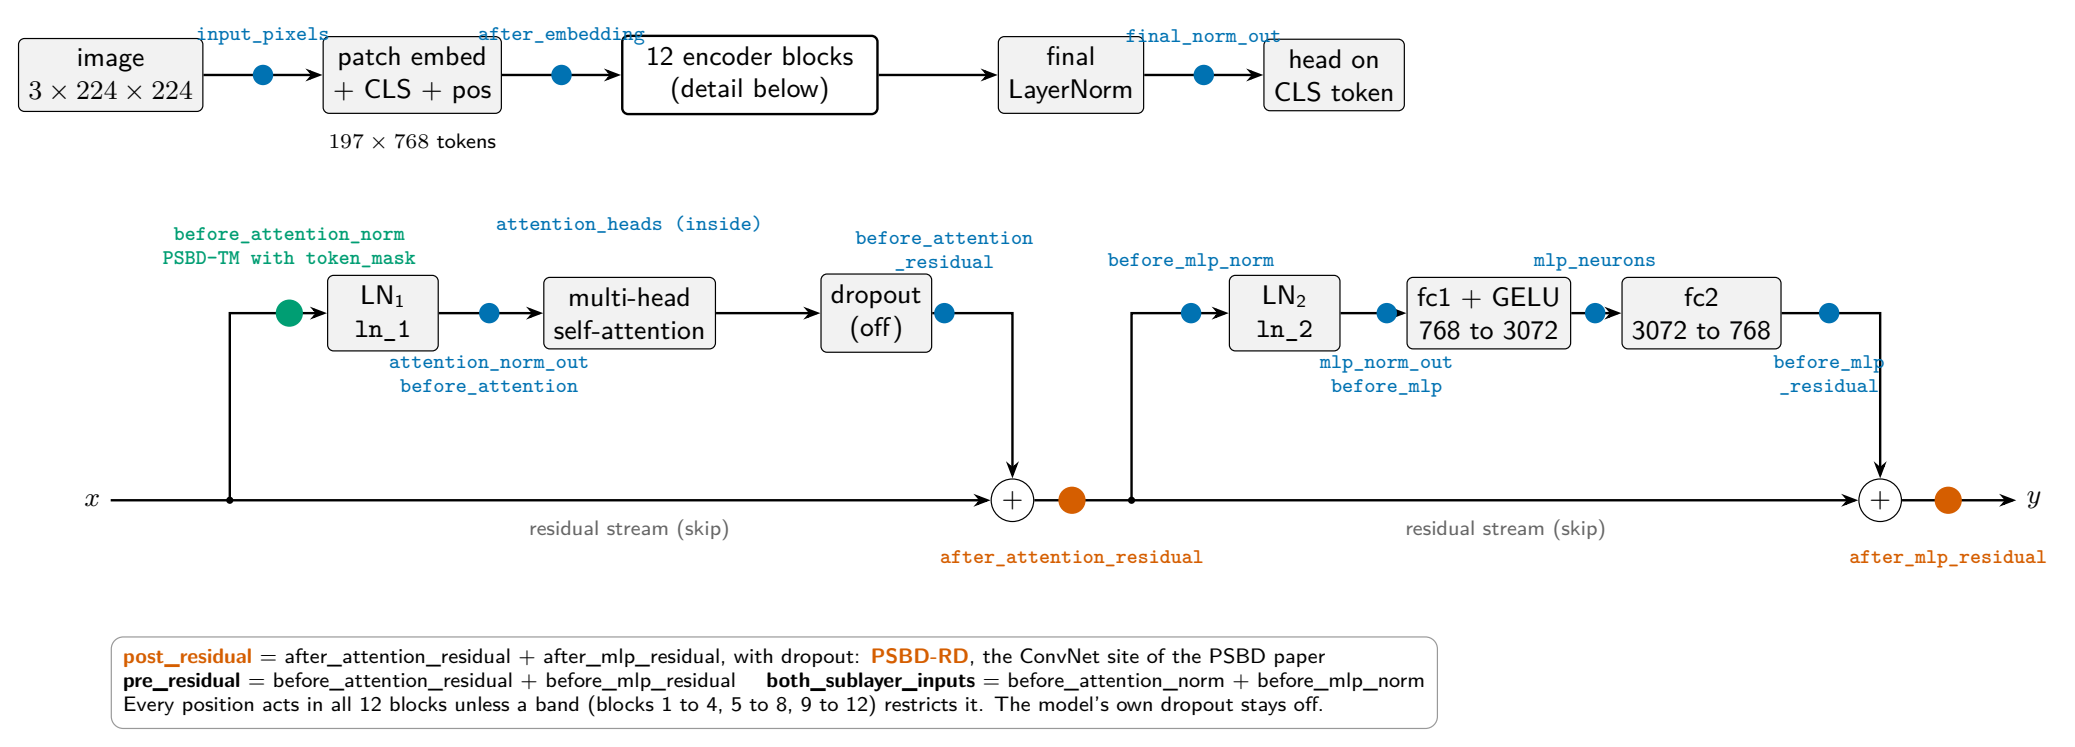

attention-side positions read by tab_attention: ('before_attention_norm', 'before_attention', 'attention_heads', 'before_attention_residual', 'after_attention_residual', 'attention_norm_out')


In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from cli.compare_detectors import psbd_values
from defenses.decision import HEADLINE_QUANTILE, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    OKABE_ITO,
    attack_label,
    bootstrap_ci,
    clearing_cells,
    fmt,
    load_coverage,
    load_declaration,
    load_psbd_metrics,
    mean_or_none,
    placement_words,
)
from scripts.paper._style import TEXT_WIDTH, attack_color, legend_above
from scripts.paper.tab_attention import ATTENTION_POSITIONS, MIN_CELLS, RULE, TPR_KEYS, readings

show_diagram("vit_block_positions")
print("attention-side positions read by tab_attention:", ATTENTION_POSITIONS)

## Probe means

The generator's own `readings` collects every successful model's AUROC and its TPR at the 10% and 20% quantiles for each attention probe. Coverage is uneven, since the probes outside the basis were swept on a subset of the panel, so the means in this table are not paired.

In [2]:
declaration = load_declaration("configs/psbd_basis.json")
declared = {entry["id"] for entry in declaration["basis"]}
folders = [cell["folder_name"] for cell in clearing_cells(load_coverage("results"))]
found = readings("results", folders)

probe_rows = []
for placement, values in found.items():
    if len(values["auroc"]) < MIN_CELLS:
        continue
    probe_rows.append(
        {
            "placement": placement,
            "probe": placement_words(placement),
            "in basis": placement in declared,
            "n": len(values["auroc"]),
            "AUROC": mean_or_none(values["auroc"]),
            "TPR@10": mean_or_none(values[TPR_KEYS[0]]),
            "TPR@20": mean_or_none(values[TPR_KEYS[1]]),
        }
    )
probes = pd.DataFrame(probe_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)

assert str(len(probes)) == macro("attention_probes", "AttentionProbesTotal")
assert str(int(probes["in basis"].sum())) == macro("attention_probes", "AttentionProbesInBasis")
outside_best = probes[~probes["in basis"]].iloc[0]
assert fmt(outside_best["AUROC"]) == macro("attention_probes", "AttentionProbesBestOutside")
print(f"{len(folders)} successful models, rule {RULE}, threshold at the {HEADLINE_QUANTILE:.0%} quantile")
print(f"{len(probes)} attention probes with at least {MIN_CELLS} models, {probes['in basis'].sum()} in the basis")
probes.drop(columns="placement").round(3)

56 successful models, rule adaptive, threshold at the 25% quantile
19 attention probes with at least 5 models, 11 in the basis


,probe,in basis,n,AUROC,TPR@10,TPR@20
0,"token mask, attention input",True,54,0.963,0.887,0.916
1,"token mask, attention output before the add",True,54,0.956,0.863,0.918
2,"channel mask, attention input",True,54,0.921,0.768,0.840
3,"noise, attention input after norm",False,19,0.913,0.789,0.867
4,"dropout, attention input",True,54,0.903,0.715,0.815
5,"head mask, attention heads",False,36,0.899,0.750,0.847
6,"token mask, attention input after norm",False,36,0.877,0.755,0.814
7,"drop path, attention output before the add",False,36,0.875,0.666,0.793
8,"dropout, stream after the attention add",True,54,0.856,0.670,0.756
9,"channel mask, attention input after norm",False,36,0.849,0.670,0.772


## Paired gaps against PSBD-TM

An unpaired mean over a subset of the panel can differ from a mean over the whole panel only because the subset holds easier models. The paired gap reads each probe against PSBD-TM on exactly the models carrying both, with a 95% bootstrap interval over those models (`BOOTSTRAP_RESAMPLES` resamples at `BOOTSTRAP_SEED`).

In [3]:
reports = {folder: load_psbd_metrics("results", folder) or {} for folder in folders}


def headline_auroc(report, placement):
    block = psbd_values(report, placement, RULE)
    if block is None or block.get(HEADLINE_KEY) is None:
        return None
    return block[HEADLINE_KEY].get("auroc")


gap_rows = []
for placement in probes["placement"]:
    deltas = []
    for report in reports.values():
        probe_auroc = headline_auroc(report, placement)
        recommended_auroc = headline_auroc(report, RECOMMENDED_PLACEMENT)
        if probe_auroc is not None and recommended_auroc is not None:
            deltas.append(probe_auroc - recommended_auroc)
    low, high = bootstrap_ci(deltas, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    gap_rows.append({"placement": placement, "paired n": len(deltas), "gap": mean_or_none(deltas), "low": low, "high": high})

probes = probes.merge(pd.DataFrame(gap_rows), on="placement")
outside = probes[~probes["in basis"]]
beating = outside[outside["low"] > 0]
print(f"probes outside the basis whose paired gap interval sits above 0: {len(beating)}")
print(f"largest paired gap outside the basis: {outside['gap'].max():+.3f}")
by_id = probes.set_index("placement")
twin_id = "before_attention_residual_token_mask"
not_twin = probes[(probes["placement"] != RECOMMENDED_PLACEMENT) & (probes["placement"] != twin_id)]
assert (not_twin["high"] < 0).all() and by_id.loc[twin_id, "low"] < 0 < by_id.loc[twin_id, "high"], "the reading says only the twin ties"
best_outside = outside.sort_values("gap", ascending=False).head(2)
weakest = probes.sort_values("AUROC").iloc[0]
probes[["probe", "in basis", "paired n", "gap", "low", "high"]].round(3)

probes outside the basis whose paired gap interval sits above 0: 0
largest paired gap outside the basis: -0.071


,probe,in basis,paired n,gap,low,high
0,"token mask, attention input",True,54,0.000,0.000,0.000
1,"token mask, attention output before the add",True,54,-0.007,-0.030,0.016
2,"channel mask, attention input",True,54,-0.042,-0.068,-0.018
3,"noise, attention input after norm",False,19,-0.071,-0.136,-0.023
4,"dropout, attention input",True,54,-0.060,-0.096,-0.031
5,"head mask, attention heads",False,36,-0.085,-0.117,-0.057
6,"token mask, attention input after norm",False,36,-0.106,-0.181,-0.044
7,"drop path, attention output before the add",False,36,-0.109,-0.150,-0.073
8,"dropout, stream after the attention add",True,54,-0.107,-0.168,-0.053
9,"channel mask, attention input after norm",False,36,-0.134,-0.192,-0.084


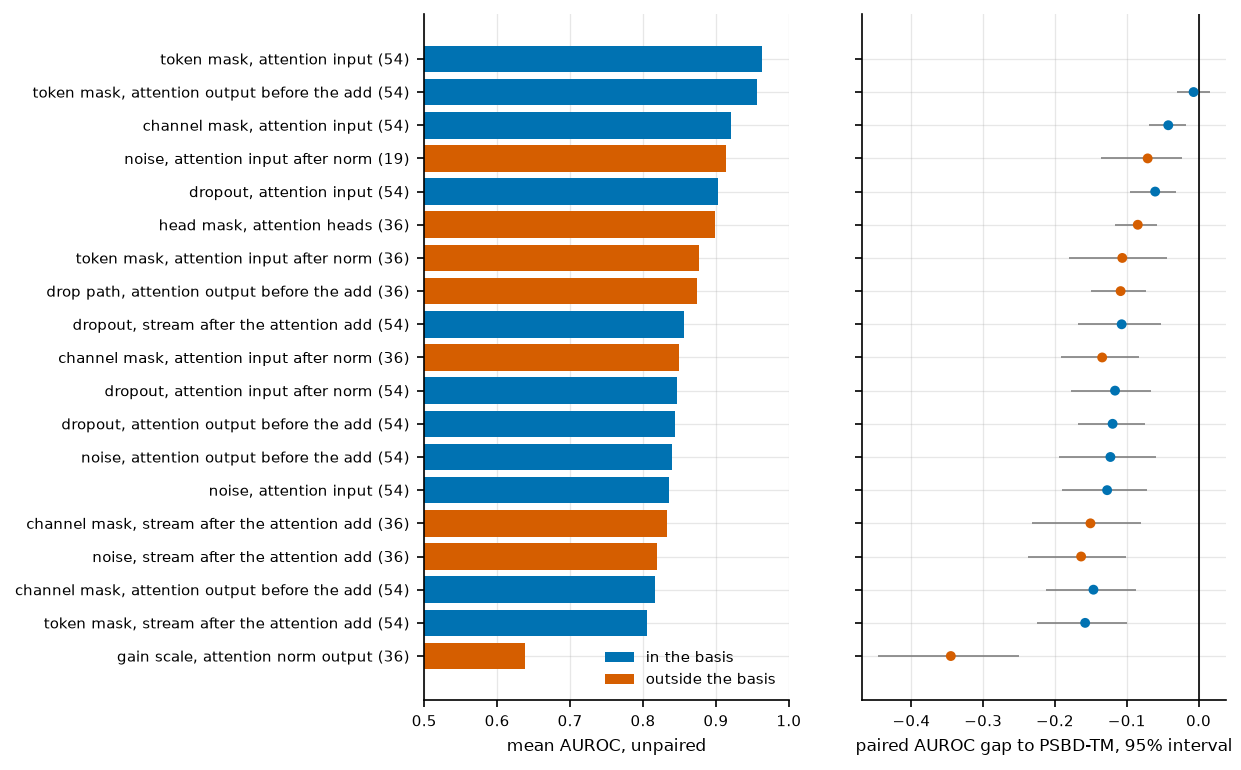

In [4]:
figure, (mean_axis, gap_axis) = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 0.26 * len(probes) + 1.0), sharey=True)
positions = np.arange(len(probes))  # (probes,)
bar_colors = [OKABE_ITO[0] if in_basis else OKABE_ITO[1] for in_basis in probes["in basis"]]

mean_axis.barh(positions, probes["AUROC"], color=bar_colors)
mean_axis.set_yticks(positions, labels=[f"{probe} ({n})" for probe, n in zip(probes["probe"], probes["n"])])
mean_axis.invert_yaxis()
mean_axis.set_xlim(0.5, 1.0)
mean_axis.set_xlabel("mean AUROC, unpaired")
mean_axis.bar(0, 0, color=OKABE_ITO[0], label="in the basis")
mean_axis.bar(0, 0, color=OKABE_ITO[1], label="outside the basis")
mean_axis.legend()

# The PSBD-TM row is the reference itself, so its gap is 0 by construction and is
# left out of the right panel.
is_reference = (probes["placement"] == RECOMMENDED_PLACEMENT).to_numpy()  # (probes,)
gap_errors = np.vstack([probes["gap"] - probes["low"], probes["high"] - probes["gap"]])  # (2, probes)
gap_axis.errorbar(probes["gap"][~is_reference], positions[~is_reference], xerr=gap_errors[:, ~is_reference], fmt="none", ecolor="gray", linewidth=0.8)
gap_axis.scatter(probes["gap"][~is_reference], positions[~is_reference], c=np.array(bar_colors)[~is_reference], s=14, zorder=3)
gap_axis.axvline(0.0, color="black", linewidth=0.8)
gap_axis.set_xlabel("paired AUROC gap to PSBD-TM, 95% interval")
plt.show()

In [5]:
display(Markdown(rf"""
The left panel is the table the paper prints and the right panel is the comparison that decides it. PSBD-TM ({by_id.loc[RECOMMENDED_PLACEMENT, "AUROC"]:.3f}) sits at the top together with its twin, token masking on the attention branch output before the add ({by_id.loc[twin_id, "AUROC"]:.3f}). Read in pairs, every probe but the twin has its whole interval below 0, so the wider search found no attention probe that matches the pre-registered winner (`\AttentionProbesBeatingRecommended` is {macro("attention_probes", "AttentionProbesBeatingRecommended")}). The strongest probes the basis never declared are {word_list([f"'{r.probe}' ({r.n} models, gap {r.gap:+.3f})" for r in best_outside.itertuples()])}. The weakest of all is '{weakest["probe"]}' ({weakest["AUROC"]:.3f}). The figure does not say whether the ranking holds on every attack, which the next figure checks for the strongest probes.
"""))


The left panel is the table the paper prints and the right panel is the comparison that decides it. PSBD-TM (0.963) sits at the top together with its twin, token masking on the attention branch output before the add (0.956). Read in pairs, every probe but the twin has its whole interval below 0, so the wider search found no attention probe that matches the pre-registered winner (`\AttentionProbesBeatingRecommended` is 0). The strongest probes the basis never declared are 'noise, attention input after norm' (19 models, gap -0.071) and 'head mask, attention heads' (36 models, gap -0.085). The weakest of all is 'gain scale, attention norm output' (0.638). The figure does not say whether the ranking holds on every attack, which the next figure checks for the strongest probes.


## The strongest probes per attack

A probe that trails PSBD-TM on average could still lead on the attacks PSBD-TM handles worst. The heatmap reads the highest-ranked probes carried by at least 30 models, averaged per attack over the successful models carrying each probe.

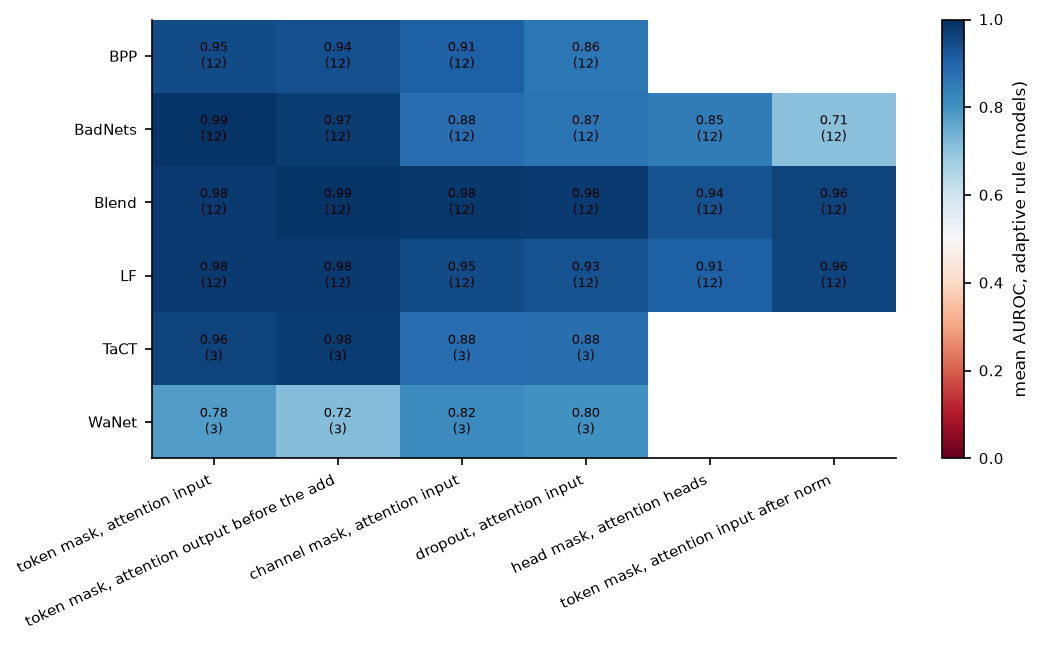

In [6]:
attack_of = {cell["folder_name"]: cell["attack"] for cell in clearing_cells(load_coverage("results"))}
top = probes[probes["n"] >= 30].head(6)
per_attack_rows = []
for folder, report in reports.items():
    for placement, probe in zip(top["placement"], top["probe"]):
        auroc = headline_auroc(report, placement)
        if auroc is not None:
            per_attack_rows.append({"attack": attack_label(attack_of[folder]), "probe": probe, "auroc": auroc})
per_attack = pd.DataFrame(per_attack_rows).pivot_table(index="attack", columns="probe", values="auroc", aggfunc="mean")[list(top["probe"])]
counts = pd.DataFrame(per_attack_rows).pivot_table(index="attack", columns="probe", values="auroc", aggfunc="size")[list(top["probe"])]

figure, axis = plt.subplots(figsize=(8.0, 3.8))
image = axis.imshow(per_attack.to_numpy(), cmap="RdBu", vmin=0.0, vmax=1.0, aspect="auto")
for r in range(per_attack.shape[0]):
    for c in range(per_attack.shape[1]):
        value = per_attack.iat[r, c]
        if not pd.isna(value):
            axis.text(c, r, f"{value:.2f}\n({int(counts.iat[r, c])})", ha="center", va="center", fontsize=6)
axis.set_xticks(range(per_attack.shape[1]), labels=per_attack.columns, rotation=25, ha="right", fontsize=7)
axis.set_yticks(range(per_attack.shape[0]), labels=per_attack.index)
axis.grid(False)
figure.colorbar(image, ax=axis, label="mean AUROC, adaptive rule (models)")
plt.show()
missing_cells = {probe: sorted(per_attack.index[per_attack[probe].isna()]) for probe in per_attack.columns if per_attack[probe].isna().any()}
tm_col, twin_col = top["probe"].iloc[0], placement_words(twin_id)

In [7]:
display(Markdown(rf"""
The small numbers are the models behind each cell. Among the columns, {word_list([f"'{p}' has no reading on {word_list(a)}" for p, a in missing_cells.items()])}, so those columns have gaps. On Blend and LF every probe reads at least {per_attack.loc[["Blend", "LF"]].min().min():.2f}. On BadNets the 2 token masks on the attention branch read {per_attack.loc["BadNets", tm_col]:.2f} and {per_attack.loc["BadNets", twin_col]:.2f}, and the other probes between {per_attack.loc["BadNets"].drop([tm_col, twin_col]).min():.2f} and {per_attack.loc["BadNets"].drop([tm_col, twin_col]).max():.2f}. The patching record of `mechanism.ipynb` says the BadNets decision sits in the trigger's own tokens until the late blocks, which fits a whole-token mask on the branch doing best, but no experiment here isolates why masking after the norm or a single head does worse. The twin reads {per_attack.loc["WaNet", twin_col]:.2f} on WaNet against {per_attack.loc["WaNet", tm_col]:.2f}. The heatmap does not pair the columns, so a column with fewer models is not directly comparable to its neighbor, and the paired gaps above remain the deciding comparison.
"""))


The small numbers are the models behind each cell. Among the columns, 'head mask, attention heads' has no reading on BPP, TaCT and WaNet and 'token mask, attention input after norm' has no reading on BPP, TaCT and WaNet, so those columns have gaps. On Blend and LF every probe reads at least 0.91. On BadNets the 2 token masks on the attention branch read 0.99 and 0.97, and the other probes between 0.71 and 0.88. The patching record of `mechanism.ipynb` says the BadNets decision sits in the trigger's own tokens until the late blocks, which fits a whole-token mask on the branch doing best, but no experiment here isolates why masking after the norm or a single head does worse. The twin reads 0.72 on WaNet against 0.78. The heatmap does not pair the columns, so a column with fewer models is not directly comparable to its neighbor, and the paired gaps above remain the deciding comparison.


## PSBD-TM against its twin

The twin, token masking on the attention branch output before the add, is the 1 probe the paired test cannot separate from PSBD-TM on ViT. Both remove whole tokens from the attention branch only, 1 at its input and 1 at its output and neither touches the skip. The scatter pairs them model by model.

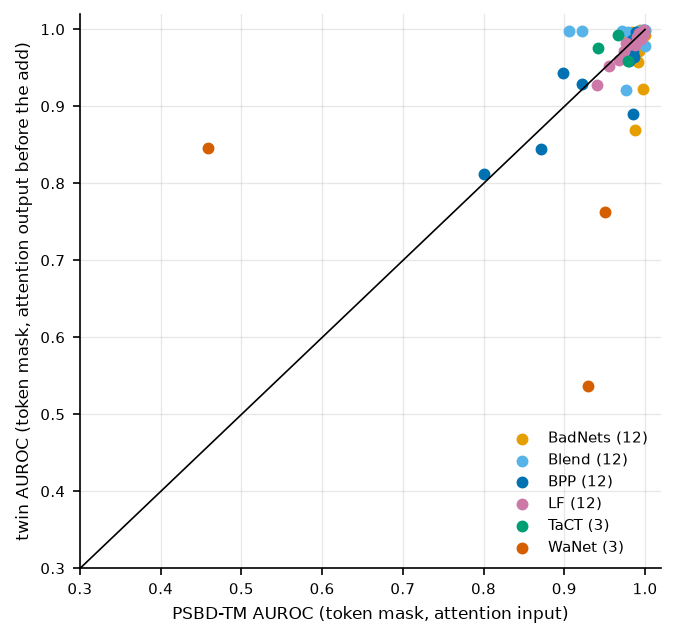

54 models carry both, mean gap twin minus PSBD-TM -0.007, correlation 0.40


In [8]:
twin = "before_attention_residual_token_mask"
pairs = []
for folder, report in reports.items():
    tm, tw = headline_auroc(report, RECOMMENDED_PLACEMENT), headline_auroc(report, twin)
    if tm is not None and tw is not None:
        pairs.append({"folder": folder, "attack": attack_of[folder], "PSBD-TM": tm, "twin": tw})
pairs = pd.DataFrame(pairs)
figure, axis = plt.subplots(figsize=(5.0, 4.8))
for attack, rows in pairs.groupby("attack"):
    axis.scatter(rows["PSBD-TM"], rows["twin"], s=22, color=attack_color(attack), label=f"{attack_label(attack)} ({len(rows)})")
axis.plot([0, 1], [0, 1], color="black", lw=0.8)
axis.set_xlim(0.3, 1.02)
axis.set_ylim(0.3, 1.02)
axis.set_xlabel("PSBD-TM AUROC (token mask, attention input)")
axis.set_ylabel("twin AUROC (token mask, attention output before the add)")
axis.legend()
plt.show()
correlation = np.corrcoef(pairs["PSBD-TM"], pairs["twin"])[0, 1]
print(f"{len(pairs)} models carry both, mean gap twin minus PSBD-TM {(pairs['twin'] - pairs['PSBD-TM']).mean():+.3f}, correlation {correlation:.2f}")
pair_gap = pairs["twin"] - pairs["PSBD-TM"]  # (models,)
twin_ahead = pairs[pair_gap > 0.05]
twin_behind = pairs[pair_gap < -0.05]

In [9]:
display(Markdown(rf"""
Most models sit in the top right corner near the diagonal, and the correlation across models is {correlation:.2f}, low because nearly all of them are packed near 1 with little spread to correlate. The twin reads more than 0.05 above PSBD-TM on {len(twin_ahead)} models ({word_list(sorted({attack_label(a) for a in twin_ahead["attack"]}))}) and more than 0.05 below on {len(twin_behind)} ({word_list(sorted({attack_label(a) for a in twin_behind["attack"]}))}). The mean gap is {pair_gap.mean():+.3f} because these cancel, so on ViT the 2 are the same probe on average but not model by model. On Swin-S they separate by {macro("swin", "SwinGainRecommendedMinusTwin")} in PSBD-TM's favor (`\SwinGainRecommendedMinusTwin`, `swin-and-robustness.ipynb`), which is why the paper names the input placement and records the ViT tie as an open question (`docs/open-questions.md`, Q20). The scatter does not say why masking the output of windowed attention is weaker on Swin, which is open.
"""))


Most models sit in the top right corner near the diagonal, and the correlation across models is 0.40, low because nearly all of them are packed near 1 with little spread to correlate. The twin reads more than 0.05 above PSBD-TM on 3 models (Blend and WaNet) and more than 0.05 below on 6 (BPP, BadNets, Blend and WaNet). The mean gap is -0.007 because these cancel, so on ViT the 2 are the same probe on average but not model by model. On Swin-S they separate by +0.128 in PSBD-TM's favor (`\SwinGainRecommendedMinusTwin`, `swin-and-robustness.ipynb`), which is why the paper names the input placement and records the ViT tie as an open question (`docs/open-questions.md`, Q20). The scatter does not say why masking the output of windowed attention is weaker on Swin, which is open.
